# Hackathon 1, statistics.

This project illustrates the statistics part of the course LEPL1109. In the first part of the project, you will study the China water pollution by analyzing a dataset providing the water pollution levels collected from various monitoring stations across 10 major provinces in China throughout the year 2023. In the second part of the project, you will analyze a dataset containing high-frequency time-series  data collected from an industrial boiler operating in a chemical plant.

## Report content

•	Grades are granted to the members whose names are in the Jupyter notebook. If your name doesn’t appear on the top of the notebook, you’ll get a 0, even though you are in a group on Moodle.

•	The jupyter notebook must be compiled with printed results and next submitted via moodle. The absence of compiled results (or non-printed values) leads to a lower grade.

•	Do not comment your results directly into cells of code. Use instead a Markdown cell. 

•	"Dry" code or results not followed by a minimum of analysis / comments will be penalized.


## Report submission

•	Deadline, see moodle website. Submission after the deadline will not be accepted.

•	To submit your report, go to the section “APP” on Moodle and the subsection “Soumission du rapport”. You can upload your work there. Once you are sure that it is your final version, click the button “Envoyer le devoir”. It is important that you don’t forget to click on this button ! 

•	Reports that have not been uploaded through Moodle will not be corrected.


## Names and Noma of participants:

Part. 1: Djoukouo Noubissi Marie Pascale

Part. 2: Kryvobokova Kateryna

Part. 3: Pinter Aurélie

Part. 4: Rencelot Maëlle

Part. 5: Tannir Dana

Part. 6: Van Aster Margaux

# China Water Pollution 

This dataset provides  water pollution levels collected from various monitoring stations across 10 major provinces in China throughout the year 2023. The data  includes  parameters such as pH, turbidity, chemical and biological oxygen demand, nutrient levels, and heavy metal concentrations. These indicators are widely used by environmental monitoring agencies to assess water quality for ecological, human, and industrial impacts.

We will focus on the Water Quality Index. 

## 1. Basic statistics

In [15]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

import statsmodels.api as sm # pour la regression via OLS()
from sklearn.model_selection import train_test_split # pour le split train/test

from sklearn.gaussian_process.kernels import RBF, Matern
from sklearn.gaussian_process import GaussianProcessRegressor

1.a) Load the dataset 'china_water_pollution_data_hack.csv'. Convert Province, City  to categorical variables. (**0.5 pt**) 

In [16]:
#code here
df = pd.read_csv(r"china_water_pollution_data_hack.csv", dtype={"Province": "category", "City" : "category", "Water_Quality_Index" : "float"}, parse_dates=["Date"])

1.b) Calculate the mean, variance, median, 25% and 75% quantiles of the water quality index (which ranges from 0 to 100) for all cities in the dataset. Comment your results! (**1.5 pts**)

In [17]:
#code here
dict_stat = {}      # Dictionnaire de la forme : {city : [mean, variance, median, 25% quantile, 75% quantile]} pour chaque ville du dataset
for city in df["City"].unique():
    dict_stat[city] = []
    wqi_city = df.loc[df["City"] == city, "Water_Quality_Index"]
    dict_stat[city].append(pd.Series.mean(wqi_city))
    dict_stat[city].append(pd.Series.var(wqi_city))
    dict_stat[city].append(pd.Series.median(wqi_city))
    dict_stat[city].append(wqi_city.quantile(q=0.25))
    dict_stat[city].append(wqi_city.quantile(q=0.75))

Comment here:

## 2. Hypothesis tests 

2.a) Check with a Student's T test that the average water quality index is the same in Shenzhen and Dali: $$H_0: \mu_{Shenzhen} = \mu_{Dali},$$ 
$$H_1: \mu_{Shenzhen} \neq \mu_{Dali}$$ 
Calculate all statistics and p-value without recourse to other functions than statistical distributions (use course's formula). Use a confidence level of 5%. Take care to comment your conclusions. Are all assumptions required to perform this test sastisfied? Which additional test do you have to do to validate your result? (**2.5 pts**)

In [18]:

X1 = df[df["City"] == "Shenzhen"]["Water_Quality_Index"]
X2 = df[df["City"] == "Dali"]["Water_Quality_Index"]
n1 = len(X1)
n2 = len(X2)

alpha = 0.05

#moyennes
Xb1 = dict_stat.get("Shenzhen")[0]
Xb2 = dict_stat.get("Dali")[0]
#variances
Var1 = dict_stat.get("Shenzhen")[1]
Var2= dict_stat.get("Dali")[1]
#écarts-type
S1 = np.sqrt(Var1)
S2 = np.sqrt(Var2)

#test d'égalité des variances (Fisher)
print("- Test d'égalité des variances (Fisher) :" )
F_obs= Var1/Var2
f_u=st.f.ppf(q=1-alpha,dfn=n1-1, dfd=n2-1)

print("F_obs :",np.round(F_obs,4))
print("f_u :" ,np.round(f_u))

pval = 1-st.f.cdf(F_obs,dfn=n1-1 , dfd=n2-1)
print("p_val: ",np.round(pval,4))
if pval < 0.05:
    print("\n--> Conclusion: On rejette H0 (α=0.05).")
else:
    print("\n--> Conclusion: On ne rejette pas H0 — Les 2 variances sont égales")

print("\n- Comparaison des 2 moyennes :" )
#comparaison 
Spool = np.sqrt(((n1-1)*S1**2 + (n2-1)*S2**2)/(n1+n2-2))
Tx = (Xb1-Xb2)/(Spool*np.sqrt(1/n1 + 1/n2))
t_l = st.t.ppf(q=alpha/2, df=n1+n2-2)
t_u = st.t.ppf(q = 1-alpha/2, df = n1+n2-2)
#print("Toutes les valeurs sont arrondies à 2 décimales \n")
print("Intervalle de confiance (IC) : ", [np.round(t_l,4), np.round(t_u,4)])
print("T(x) :", np.round(Tx,4))
pval = 2*st.t.cdf(-np.abs(Tx), df = n1+n2-2)
print("P-value :" , np.round(pval,4))
if pval < 0.05:
    print("\n--> Conclusion: On rejette H0 — au moins une moyenne diffère (α=0.05).")
else:
    print("\n--> Conclusion: On ne rejette pas H0 — pas de différence globale détectée (α=0.05).")

- Test d'égalité des variances (Fisher) :
F_obs : 0.8774
f_u : 1.0
p_val:  0.7874

--> Conclusion: On ne rejette pas H0 — Les 2 variances sont égales

- Comparaison des 2 moyennes :
Intervalle de confiance (IC) :  [-1.968, 1.968]
T(x) : 7.6701
P-value : 0.0

--> Conclusion: On rejette H0 — au moins une moyenne diffère (α=0.05).


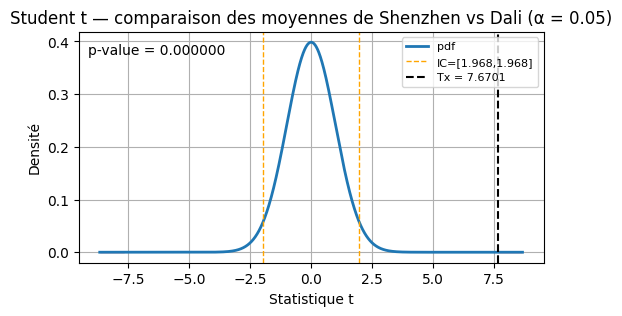

In [19]:
### AFFICHAGE DES RESULTATS
df_t = n1 + n2 - 2
# domaine pour le tracé (ne recalcule pas Tx)
x_max = max(4, abs(Tx)+1 , abs(t_u) * 1.5)
x = np.linspace(-x_max, x_max, 2000)
y = st.t.pdf(x, df_t)

plt.figure(figsize=(6,3))
plt.plot(x, y, lw=2, label=f"pdf")
plt.fill_between(x, y, where=(x <= -abs(Tx)), color="red", alpha=0.4)
plt.fill_between(x, y, where=(x >=  abs(Tx)), color="red", alpha=0.4)
plt.axvline(t_l, color="orange", ls="--", lw=1, label=f"IC=[{t_u:.3f},{t_u:.3f}]")
plt.axvline(t_u, color="orange", ls="--", lw=1)
plt.axvline(Tx, color="k", ls="--", lw=1.5, label=f"Tx = {Tx:.4f}")
plt.title(f"Student t — comparaison des moyennes de Shenzhen vs Dali (α = {alpha})")
plt.xlabel("Statistique t")
plt.ylabel("Densité")
plt.legend(loc="upper right",fontsize=8)
plt.grid(True)
plt.text(0.02, 0.95, f"p-value = {pval:.6f}", transform=plt.gca().transAxes, va="top")

plt.show()

Comment here:

Après avoir calculé la statistique $T(x)$, les bornes critiques inférieures et supérieures (t_l,t_u) de l'interval de confiance (IC) ainsi que la p-value, on peut décider de rejeter ou non l'hypothèse $H_0$. 

#### Hypothèses:

- La variable suit approximativement une distribution normale comme discuté au point 1.a

- Les 2 échantillons sont indépendants entre eux. En effet, les villes se situant à plus de 1400 kilomètres de distance, elles sont suffisamment éloignées l'une de l'autre pour que leurs données ne s'influencent pas.

- Le test Fisher nous assure l'égalité des variances. En effet, la p-value est de 78% ce qui est > $\alpha$ = 5%. On ne rejette pas $$H_0:  \sigma_{Shenzhen}^2 = \sigma_{Dali}^2$$. Ce qui démontre l'égalité des variances.


#### Observations :
 
Tout d'abord, on sait que l'intervalle pour lequel on ne rejette pas $H_0$ est [ t_l , t_u ] = [-1.968, 1.968]. Grâce au graphe, on voit que la statistique $T(x)=$ 7.6701 est < que t_u = 1,968 (borne supérieure de IC) --> $T(x) \notin$ IC , on se retrouve dans la zone de rejet.  

Ensuite, la p-value nous permet également de décider. On voit que la P-value = 0 est < $\alpha$ (avec $\alpha$ = 5%).

#### Conclusion :

Chacun de ses résultats ($T(x)$ dans la zone de rejet et p-value < $\alpha $) nous permet de décider de rejeter $H_0$. Par conséquent, les moyennes sont significativement différentes. De plus, comme la valeur de la p-value est extrêmement proche de zéro, l'hypothèse $H_0$ est très peu probable.

2.b) 'Wuhan', 'Luoyang', 'Chengdu', 'Nanjing', 'Dali' seems to have similar (and low) water quality index. Test the assumption: $$H_0:  \mu_{Wuhan} = \mu_{Luoyang}= \mu_{Chengdu} = \mu_{Nanjing} =\mu_{Dali}.$$
**Hint**: reformulate the problem as a linear regression.

(**2 pts**)

In [ ]:
### SET Y & X UP ###

cities = ["Wuhan", "Luoyang", "Chengdu", "Nanjing", "Dali"]
sub_df = df[df["City"].isin(cities)].copy()                             # Remove rows of data for unrelevant cities
sub_df["City"] = pd.Categorical(sub_df["City"], categories=cities)      # Remove unrelevant cities of sub_df["City"]
df_dummy = pd.get_dummies(sub_df["City"], drop_first=True, dtype=int)   # Convert relevant cities into dummy variables; excluding the first to avoid ill-posed problem

X = df_dummy
X = sm.add_constant(X)                                                  # Add constant for B_0

Y = sub_df["Water_Quality_Index"]

### LINEAR REGRESSION ###

model = sm.OLS(Y, X)
results = model.fit()

print(results.summary())

### CONCLUSION ON THE STATISTICAL TEST
print("HYPOTHESIS TESTING OF NULL HYPOTHESIS H0 : B_1 = B_2 = B_3 = B_4 = 0 (which is identical to testing whether all expected values are equal)")
alpha = 0.05
print(f"Value of statistical test F* = {results.fvalue}")
print(f"Value of quantile 0.95 of Fisher distribution with n1 = 4, n2 = {len(Y) - 4 - 1} : {st.f.ppf(0.95, 4, (len(Y) - 4 - 1))}")
print(f"P-value : {results.f_pvalue}")

print(" ")
### BARTLETT'S TEST FOR EQUALITY OF VARIANCES ###
print("HYPOTHESIS TESTING OF HYPOTHESIS H_0 : equality of the variances of the considered cities")
stat, pvalue = st.bartlett(sub_df.loc[sub_df["City"] == "Wuhan", "Water_Quality_Index"], sub_df.loc[sub_df["City"] == "Luoyang", "Water_Quality_Index"], sub_df.loc[sub_df["City"] == "Chengdu", "Water_Quality_Index"], sub_df.loc[sub_df["City"] == "Nanjing", "Water_Quality_Index"], sub_df.loc[sub_df["City"] == "Dali", "Water_Quality_Index"])
print(f"Bartlett's test pvalue : {pvalue}")

Comment here: 

Afin de tester l'égalité de plus de 2 espérances, nous avons réalisé une ANOVA. Cela revient donc à faire une régression linéaire en "dummifiant" le dataset pour les 5 villes considérées (en introduisant donc 4 variables binaires, et non pas 5 pour éviter un problème mal conditionnné). Ensuite, nous testons l'hypothèse $H_0$ que les coefficients de la régression linéaire associés à chaque ville sont égaux à 0 (ce qui revient à tester l'égalité des espérances des cinq villes).

Nous observons que la statistique F* (directement calculée par OLS()) est inférieure au quantile 0.95 de la distribution Fisher qu'elle suit $(F_(4, 749))$ : F* = 0.9645 < 2.3838. Nous ne rejettons pas $H_0$ : les espérances peuvent être considérées égales. Par ailleurs, afin de confirmer cette conclusion, la p-value est supérieure à 5% : 0.4262 > 0.05. La p-value étant même supérieure à 0.1, nous n'avons aucune présomption contre $H_0$.

Les suppositions nécessaires à la réalisation d'une ANOVA sont :
* Les données suivent une loi normale : comme précisé au 1.b, nous observons de façon empirique à l'aide d'un graphe qu'il n'est pas déraisonnable de supposer que nos données suivent une loi normale.
* Indépendance des échantillons : la paire de villes parmi les 5 considérées les plus proches se situent à plus de 450 kilomètres l'une de l'autre. Il est donc possible de supposer les échantillons indépendants.
* Egalité des variances : nous avons vérifié l'égalité des variances avec le test de Bartlett. Nous obtenons une p-value de 0.2725, ce qui est supérieur à 0.05. Nous ne rejettons pas l'hypothèse d'égalité des variances.

## 3. Regressions

3.a) Propose a regression model which explains the Water_Quality_Index as a function of other explanatory variables, **for the city of Shanghai**. Split your data set into a training set (80% of the data) that you use for fitting the model and a test set (20% of the data) on which you test the accuracy of the model. 

* Use the OLS() function of the package statsmodels.api to perform the linear regression. 
* Comment your results (goodness of fit, R2, F-stat and T-stats of coefficients)
* Identify potential non-relevant covariates
* Calculate the MAE on the test and training sets. 

(**3 pts**)

In [20]:
#code here 
df_shanghai = df[df['City'] == 'Shanghai']   # on filtre les données de Shanghai

Y = df_shanghai['Water_Quality_Index']   # variable reponse Yi

X = df_shanghai.drop(columns=['Water_Quality_Index', 'Province', 'City', 'Date'])   # matrice des variables explicatives Xi
X = sm.add_constant(X)   # on y ajoute une colonne de 1 au début de la matrice pour le terme beta_0

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)


                             OLS Regression Results                            
Dep. Variable:     Water_Quality_Index   R-squared:                       0.777
Model:                             OLS   Adj. R-squared:                  0.761
Method:                  Least Squares   F-statistic:                     50.46
Date:                 Wed, 29 Oct 2025   Prob (F-statistic):           3.51e-66
Time:                         18:07:53   Log-Likelihood:                -544.84
No. Observations:                  249   AIC:                             1124.
Df Residuals:                      232   BIC:                             1183.
Df Model:                           16                                         
Covariance Type:             nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const         

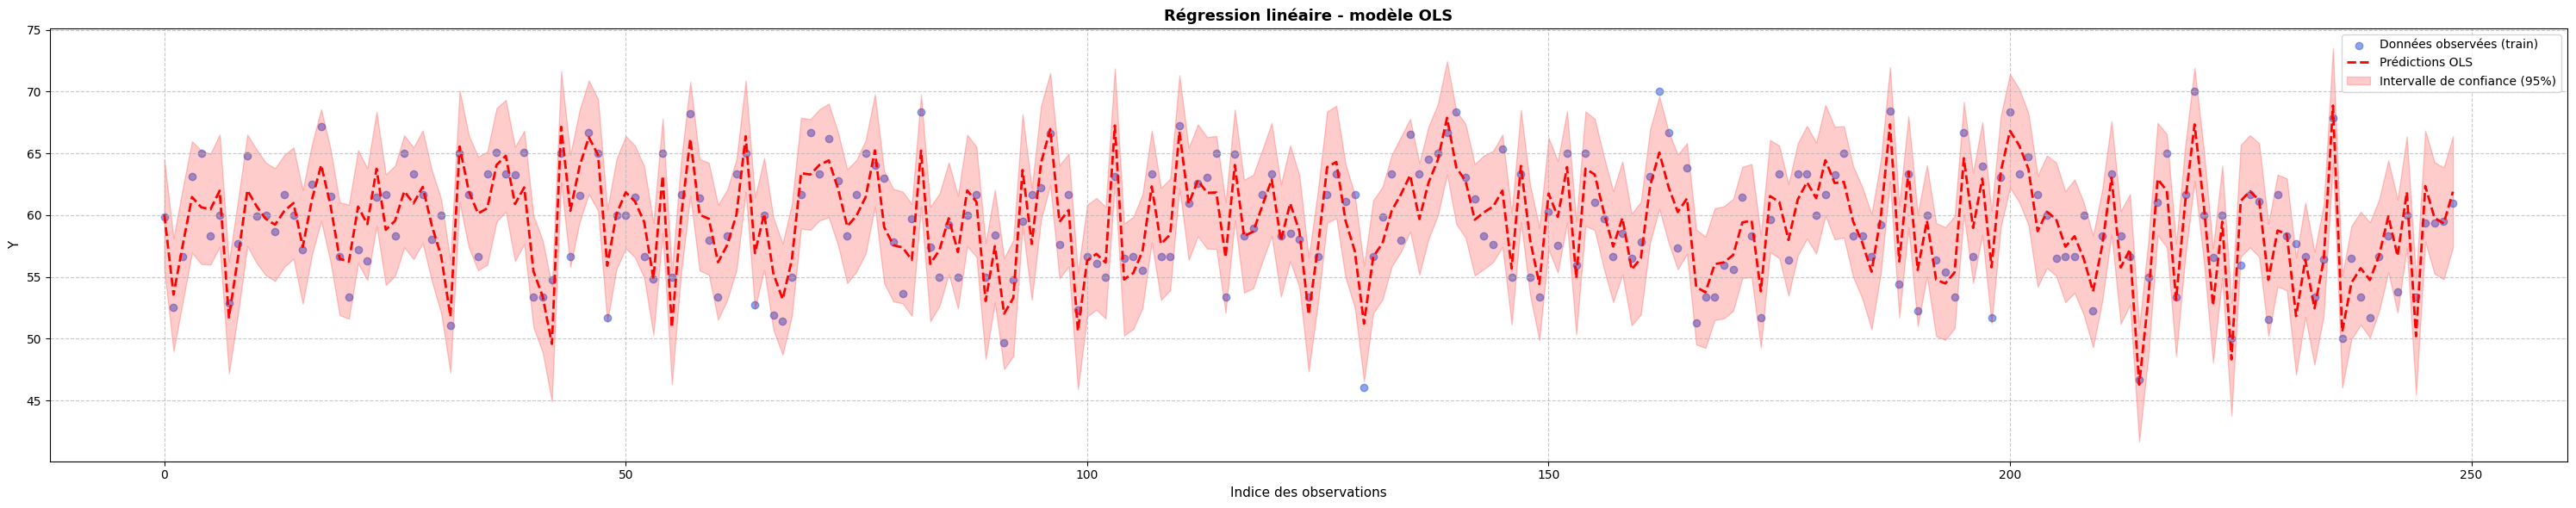

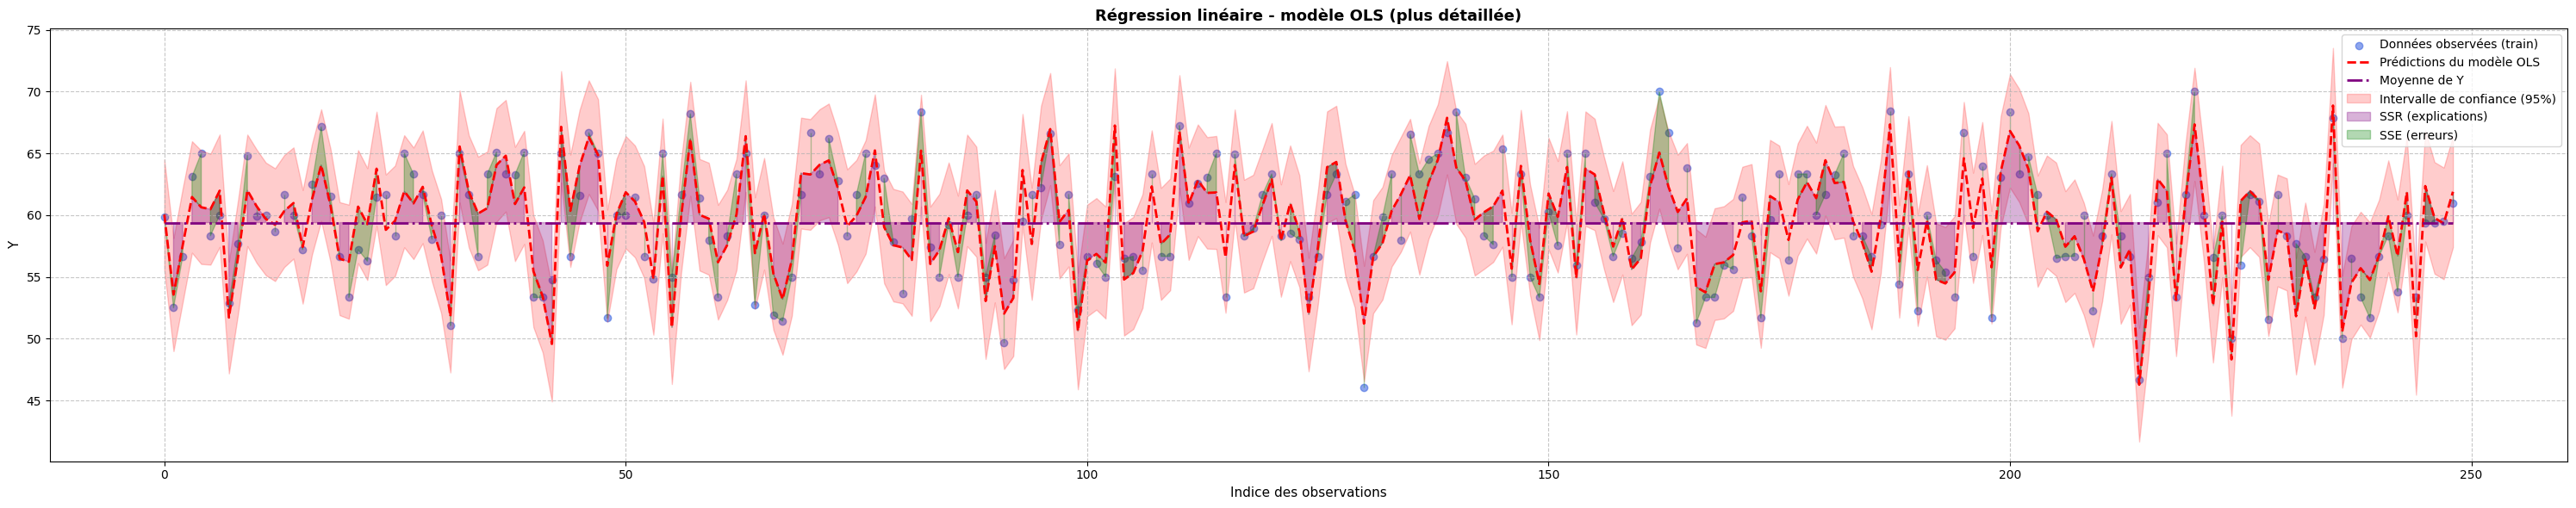

In [21]:
# modèle de régression linéaire via OLS()

model = sm.OLS(Y_train, X_train)   # création du modèle
results = model.fit()   # ajustement aux données

print(results.summary()) 

# covariables non pertinentes : si p-value > 0.05 (P>|t| dans le tableau)
# Water_Temperature_C, pH, Conductivity_uS_cm, Nitrite_mg_L et Total_Nitrogen_mg_L

mae_train = np.mean(np.abs(Y_train - results.predict(X_train)))   # calcul du MAE (Mean Absolute Error = epsilon) sur les 2 sets
mae_test = np.mean(np.abs(Y_test - results.predict(X_test)))

print("Epsilon du training set = ", mae_train)
print("Epsilon du test set = ", mae_test)

### Graphiques ###

#  ---------------- 1) Graphique ---------------- 

pred_ols = results.get_prediction(X_train)
pred_summary = pred_ols.summary_frame()

iv_l = pred_summary["obs_ci_lower"]  # borne inférieure de l'IC
iv_u = pred_summary["obs_ci_upper"]  # borne supérieure de l'IC
y_pred = results.fittedvalues         # valeurs prédites
y_true = Y_train                      # valeurs réelles

# Étendre le graphique sur l'axe des x
fig, ax = plt.subplots(figsize=(30, 6))  # largeur augmentée pour lisibilité

# Points observés
ax.scatter(range(len(y_true)), y_true, color='royalblue', alpha=0.6, label='Données observées (train)')

# Ligne des prédictions
ax.plot(range(len(y_pred)), y_pred, "r--", linewidth=2, label="Prédictions OLS")

# Bande d’incertitude
ax.fill_between(range(len(y_pred)), iv_l, iv_u, color='red', alpha=0.2, label="Intervalle de confiance (95%)")

# Titres et axes
ax.set_title("Régression linéaire - modèle OLS", fontsize=13, fontweight='bold')
ax.set_xlabel("Indice des observations", fontsize=11)
ax.set_ylabel("Y", fontsize=11)
ax.legend(loc="best")
ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show() 



#  ---------------- 2) Graphique ---------------- 

pred_ols = results.get_prediction(X_train)
pred_summary = pred_ols.summary_frame()

iv_l = pred_summary["obs_ci_lower"]
iv_u = pred_summary["obs_ci_upper"]
y_pred = results.fittedvalues
y_true = Y_train
y_mean = y_true.mean()

# Étendre le graphique sur l'axe des x
fig, ax = plt.subplots(figsize=(30, 6))

# Points observés
ax.scatter(range(len(y_true)), y_true, color='royalblue', alpha=0.6, label='Données observées (train)')

# Ligne des prédictions
ax.plot(range(len(y_pred)), y_pred, "r--", linewidth=2, label="Prédictions du modèle OLS")

# Ligne de la moyenne de Y
ax.hlines(y=y_mean, xmin=0, xmax=len(y_true)-1, colors='purple', linestyles='-.', linewidth=2, label='Moyenne de Y')

# Bande d’incertitude
ax.fill_between(range(len(y_pred)), iv_l, iv_u, color='red', alpha=0.2, label="Intervalle de confiance (95%)")

# Zone SSR (variation expliquée par le modèle)
ax.fill_between(range(len(y_pred)), y_mean, y_pred, where=(y_pred>=y_mean), color='purple', alpha=0.3, label='SSR (explications)')
ax.fill_between(range(len(y_pred)), y_mean, y_pred, where=(y_pred<y_mean), color='purple', alpha=0.3)

# Zone SSE (erreur résiduelle)
ax.fill_between(range(len(y_pred)), y_pred, y_true, where=(y_true>=y_pred), color='green', alpha=0.3, label='SSE (erreurs)')
ax.fill_between(range(len(y_pred)), y_pred, y_true, where=(y_true<y_pred), color='green', alpha=0.3)

# Titres et axes
ax.set_title("Régression linéaire - modèle OLS (plus détaillée)", fontsize=13, fontweight='bold')
ax.set_xlabel("Indice des observations", fontsize=11)
ax.set_ylabel("Y", fontsize=11)
ax.legend(loc="best")
ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Comment here : On utilise la fonction **OLS** pour calculer une régression linéaire. Cette fonction (**OLS** = *Ordinary Least Squares*) consiste à minimiser la somme des carrés des résidus. Dans ce cas-ci, on cherche à modéliser la relation entre la variable indépendante $Y$ (*Water Quality Index*) et l'ensemble des variables explicatives $X$, qui forment une matrice où chaque colonne correspond à une caractéristique de l'eau (température, pH, concentration en métaux lourds, ...).  

Notre modèle linéaire est de la forme :  

$$ Y_i = \beta_0 + \beta_1 X_{i1} + \beta_2 X_{i2} + \cdots + \beta_d X_{id} + \varepsilon_i \quad \text{pour } i = 1, \dots, n
$$ 

- $Y$ est un vecteur de taille $n$ 
- $\beta$ est un vecteur de taille $d+1$  
- \(X\) est une matrice de taille $n \times (d+1)$
- $\varepsilon_i \sim \mathcal{N}(0, \sigma^2)$ représente le bruit  

On peut ainsi réécrire notre modèle de façon matricielle :  

$$
\mathbf{Y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}
$$

Étant donné que l'on ne connaît ni $\beta$ ni $\sigma^2$, on utilise les estimations $\hat{\beta}$ et $\hat{\sigma}^2$, que l'on peut calculer grâce à la méthode de **Maximum Likelihood** :  

$$ \hat{\beta} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{Y} \quad \text{(minimise la somme des carrés des erreurs)} $$

### Goodness of fit

Pour estimer la qualité du modèle, il faut séparer la variance des observations en deux composantes : une variance expliquée par le modèle et une variance résiduelle. Plus la variance expliquée est élevée, meilleure est la qualité de l'ajustement.  

Nous observons que $R^2 = 0.777$, ce qui signifie que 77,7 % de la variance du Water Quality Index est expliquée par les variables du modèle. Plus $R^2$ est proche de 1, meilleur est le modèle. Étant donné que l'on observe des données expérimentales avec un bruit modéré, il est normal que $R^2$ ne soit pas exactement égal à 1.  

Le $R^2_{\text{ajusté}} = 0.761$, ce qui reste très proche de 77 %. Ainsi, on peut conclure que le modèle est réellement correct et non biaisé par un trop grand nombre de variables.

### F-stat

La F-statistique est de 50.46 avec une p-value proche de 0. Elle permet de tester la significativité globale du modèle linéaire et de déterminer si au moins une des variables explicatives a un effet réel sur le WQI. Ainsi, le modèle est hautement significatif globalement, et la probabilité que toutes les variables significatives soient nulles en même temps est presque nulle.

### T-stat des coefficients

Chaque coefficient $\beta_i$ a une t-statistique et une p-value associée. Si la p-value > 0,05, la variable n’est pas significativement liée à $Y$ et pourrait être considérée comme non pertinente pour le modèle.  

Dans notre cas, les covariables potentiellement non pertinentes sont :  

- Water_Temperature_C  
- pH  
- Conductivity_uS_cm  
- Nitrite_mg_L  
- Total_Nitrogen_mg_L  

Ainsi, on rejette $H_0$. Le modèle reste hautement significatif globalement.

### Covariables potentiellement non pertinentes

Si la p-value est supérieure à 5 %, la covariable est considérée comme non pertinente, car elle se trouve dans la zone de rejet. Ces variables sont donc non-utiles, contrairement à celles situées dans la zone de non-rejet.

Lorsque la déviation standard (str err) est faible en comparaison avec le coef, alors les variables sont pertinentes. Dans le cas contraire, elles sont à rejeter.

### MAE sur les ensembles d’entraînement et de test

- MAE training set = 1.76  
- MAE test set = 1.97  

Les erreurs sont faibles et proches entre le training set et le test set, ce qui indique que le modèle généralise bien.

### Analyse des graphiques

- Les points bleus représentent les valeurs observées du WQI dans le jeu d’entraînement.  
- La ligne rouge en pointillés est la prévision du modèle OLS pour ces observations.  
- La zone rouge transparente correspond à l’intervalle de confiance à 95 % autour des prédictions.  

La ligne rouge suit fidèlement les points bleus, ce qui confirme la qualité de l’ajustement. L’intervalle de confiance à 95 % capture la majorité des points, indiquant que le modèle est fiable statistiquement. Quelques points restent toutefois en dehors de l’intervalle.  

Ainsi, le graphique confirme la performance du modèle OLS : il suit correctement les tendances principales et capture la majorité des variations du WQI dans le jeu d’entraînement.

3.b) Same question as 3.a) but now you use a Gaussian process regression. Use a RBF and Matern kernel and compare MAEs of the 2 models. Which one is the best? (**2 pts**)

In [22]:
#code here
# création du modèle de GRP via les noyaux RBF et Matern 
rbf = RBF(length_scale=1.0) 
gp_rbf = GaussianProcessRegressor(kernel=rbf)

matern = Matern(length_scale=1.0, nu=1.5) 
gp_matern = GaussianProcessRegressor(kernel=matern) 

# ajustement des modèles sur le training set
gp_rbf.fit(X_train, Y_train)
gp_matern.fit(X_train, Y_train)

# calcul du MAE (Mean Absolute Error = epsilon) sur les 2 sets  
mae_train_rbf = np.mean(np.abs(Y_train - gp_rbf.predict(X_train)))
mae_test_rbf = np.mean(np.abs(Y_test - gp_rbf.predict(X_test))) 

mae_train_matern = np.mean(np.abs(Y_train - gp_matern.predict(X_train)))
mae_test_matern = np.mean(np.abs(Y_test - gp_matern.predict(X_test)))

print("Epsilon du training set RBF = ", mae_train_rbf)
print("Epsilon du test set RBF = ", mae_test_rbf)
print("Epsilon du training set Matern = ", mae_train_matern)
print("Epsilon du test set Matern = ", mae_test_matern)


Epsilon du training set RBF =  6.9514793136407835e-09
Epsilon du test set RBF =  7.110916660845637
Epsilon du training set Matern =  3.743857921581439e-09
Epsilon du test set Matern =  4.54581695518793


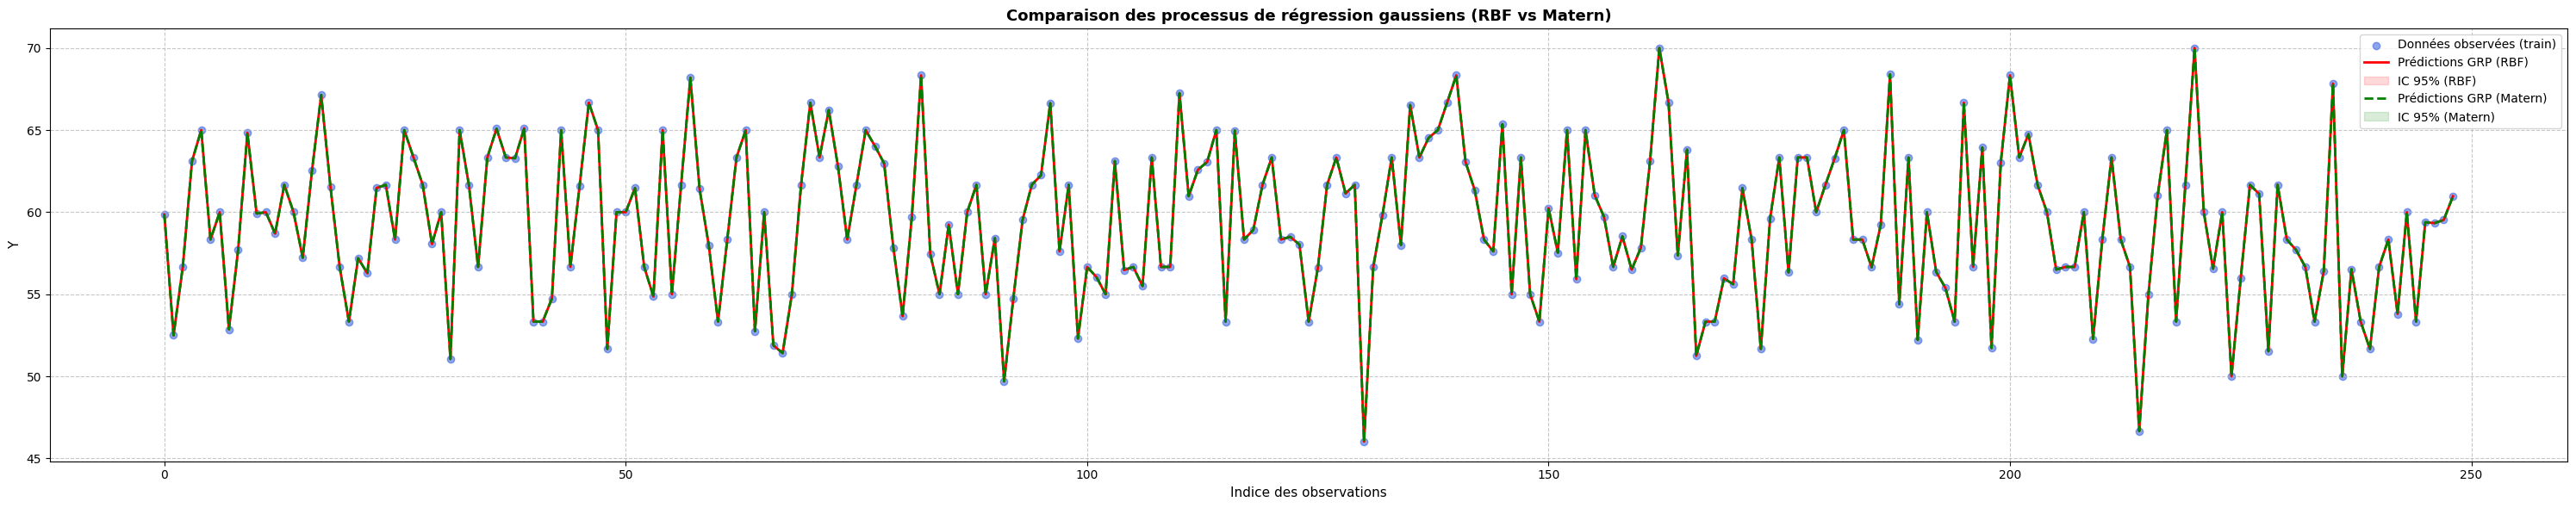

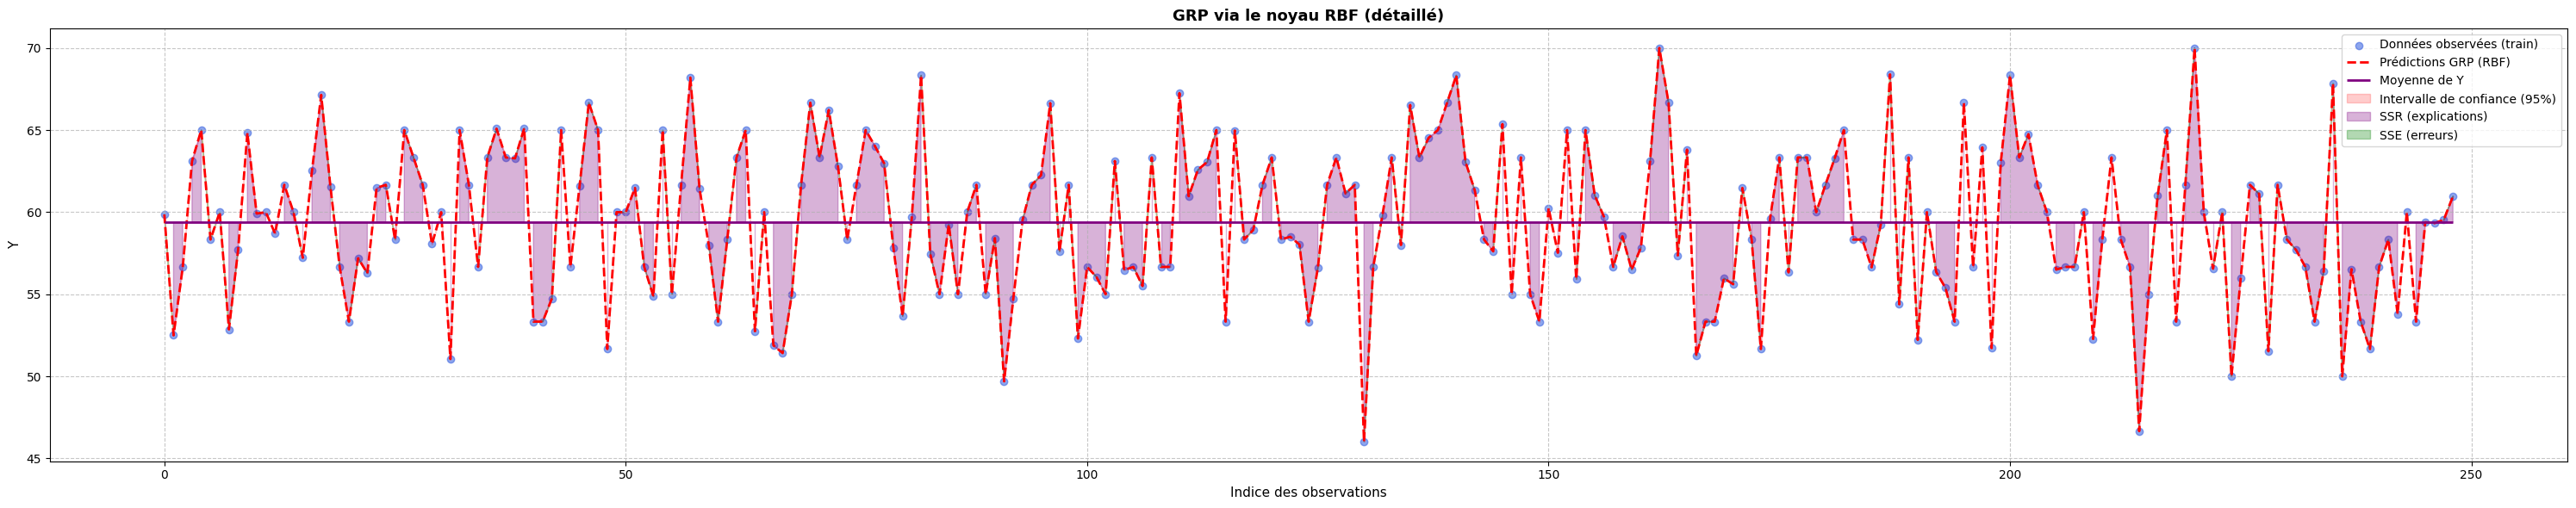

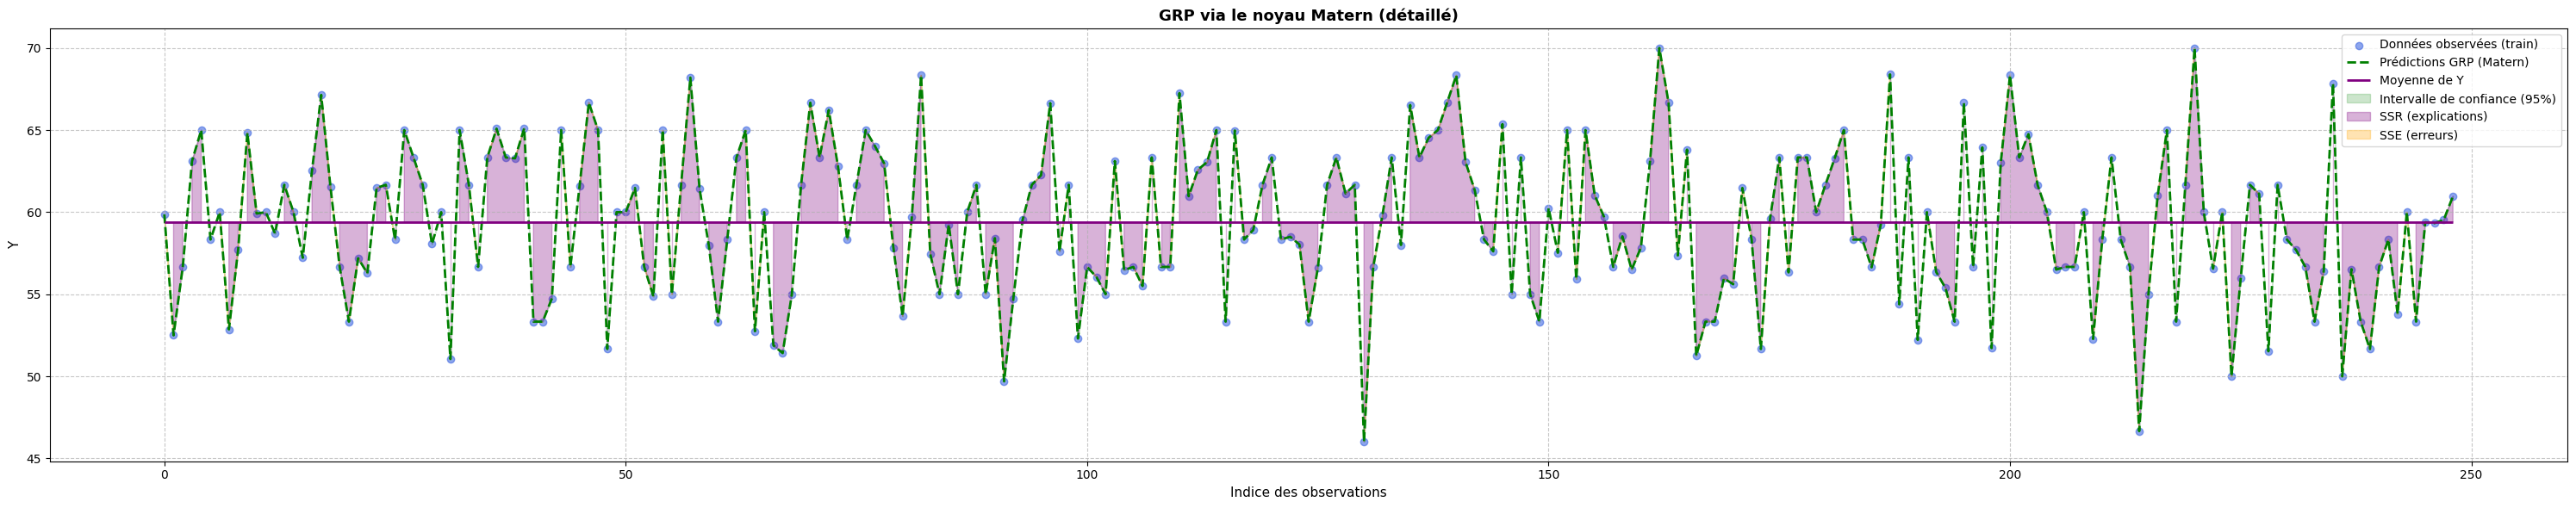

In [23]:
### Graphiques ###

# RBF
y_pred_rbf, sigma_rbf = gp_rbf.predict(X_train, return_std=True)
iv_l_rbf = y_pred_rbf - 1.96 * sigma_rbf
iv_u_rbf = y_pred_rbf + 1.96 * sigma_rbf

# Matern
y_pred_matern, sigma_matern = gp_matern.predict(X_train, return_std=True)
iv_l_matern = y_pred_matern - 1.96 * sigma_matern
iv_u_matern = y_pred_matern + 1.96 * sigma_matern

#  ---------------- 1) Graphique comparatif Matern vs RBF ---------------- 

fig, ax = plt.subplots(figsize=(30, 6))

# Données observées
ax.scatter(range(len(Y_train)), Y_train, color='royalblue', alpha=0.6, label='Données observées (train)')

# --- RBF ---
ax.plot(range(len(y_pred_rbf)), y_pred_rbf, "r-", linewidth=2, label="Prédictions GRP (RBF)")
ax.fill_between(range(len(y_pred_rbf)), iv_l_rbf, iv_u_rbf, color='red', alpha=0.15, label="IC 95% (RBF)")

# --- Matern ---
ax.plot(range(len(y_pred_matern)), y_pred_matern, "g--", linewidth=2, label="Prédictions GRP (Matern)")
ax.fill_between(range(len(y_pred_matern)), iv_l_matern, iv_u_matern, color='green', alpha=0.15, label="IC 95% (Matern)")

# Titres et axes
ax.set_title("Comparaison des processus de régression gaussiens (RBF vs Matern)", 
             fontsize=13, fontweight='bold')
ax.set_xlabel("Indice des observations", fontsize=11)
ax.set_ylabel("Y", fontsize=11)
ax.legend(loc="best")
ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


#  ---------------- 2) Graphique de prédiction du modèle GRP (noyau = RBF) ----------------

y_pred_rbf, sigma_rbf = gp_rbf.predict(X_train, return_std=True)

# Intervalle de confiance à 95%
iv_l_rbf = y_pred_rbf - 1.96 * sigma_rbf
iv_u_rbf = y_pred_rbf + 1.96 * sigma_rbf

# Moyenne de Y
y_true = Y_train
y_mean = y_true.mean()

# Création du graphique
fig, ax = plt.subplots(figsize=(30, 6))

# Points observés
ax.scatter(range(len(y_true)), y_true, color='royalblue', alpha=0.6, label='Données observées (train)')

# Ligne des prédictions
ax.plot(range(len(y_pred_rbf)), y_pred_rbf, "r--", linewidth=2, label="Prédictions GRP (RBF)")

# Ligne de la moyenne de Y
ax.hlines(y=y_mean, xmin=0, xmax=len(y_true)-1, colors='purple', linestyles='-', linewidth=2, label='Moyenne de Y')

# Bande d’incertitude
ax.fill_between(range(len(y_pred_rbf)), iv_l_rbf, iv_u_rbf, color='red', alpha=0.2, label="Intervalle de confiance (95%)")

# Zone SSR (variation expliquée par le modèle)
ax.fill_between(range(len(y_pred_rbf)), y_mean, y_pred_rbf, where=(y_pred_rbf>=y_mean), color='purple', alpha=0.3, label='SSR (explications)')
ax.fill_between(range(len(y_pred_rbf)), y_mean, y_pred_rbf, where=(y_pred_rbf<y_mean), color='purple', alpha=0.3)

# Zone SSE (erreur résiduelle)
ax.fill_between(range(len(y_pred_rbf)), y_pred_rbf, y_true, where=(y_true>=y_pred_rbf), color='green', alpha=0.3, label='SSE (erreurs)')
ax.fill_between(range(len(y_pred_rbf)), y_pred_rbf, y_true, where=(y_true<y_pred_rbf), color='green', alpha=0.3)

# Titres et axes
ax.set_title("GRP via le noyau RBF (détaillé)", fontsize=13, fontweight='bold')
ax.set_xlabel("Indice des observations", fontsize=11)
ax.set_ylabel("Y", fontsize=11)
ax.legend(loc="best")
ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()


#  ---------------- 3) Graphique de prédiction du modèle GRP (noyau = Matern) ----------------

y_pred_matern, sigma_matern = gp_matern.predict(X_train, return_std=True)

# Intervalle de confiance à 95%
iv_l_matern = y_pred_matern - 1.96 * sigma_matern
iv_u_matern = y_pred_matern + 1.96 * sigma_matern

# Moyenne de Y
y_true = Y_train
y_mean = y_true.mean()

# Création du graphique
fig, ax = plt.subplots(figsize=(30, 6))

# Points observés
ax.scatter(range(len(y_true)), y_true, color='royalblue', alpha=0.6, label='Données observées (train)')

# Ligne des prédictions
ax.plot(range(len(y_pred_matern)), y_pred_matern, "g--", linewidth=2, label="Prédictions GRP (Matern)")

# Ligne de la moyenne de Y
ax.hlines(y=y_mean, xmin=0, xmax=len(y_true)-1, colors='purple', linestyles='-', linewidth=2, label='Moyenne de Y')

# Bande d’incertitude
ax.fill_between(range(len(y_pred_matern)), iv_l_matern, iv_u_matern, color='green', alpha=0.2, label="Intervalle de confiance (95%)")

# Zone SSR (variation expliquée par le modèle)
ax.fill_between(range(len(y_pred_matern)), y_mean, y_pred_matern, where=(y_pred_matern>=y_mean), color='purple', alpha=0.3, label='SSR (explications)')
ax.fill_between(range(len(y_pred_matern)), y_mean, y_pred_matern, where=(y_pred_matern<y_mean), color='purple', alpha=0.3)

# Zone SSE (erreur résiduelle)
ax.fill_between(range(len(y_pred_matern)), y_pred_matern, y_true, where=(y_true>=y_pred_matern), color='orange', alpha=0.3, label='SSE (erreurs)')
ax.fill_between(range(len(y_pred_matern)), y_pred_matern, y_true, where=(y_true<y_pred_matern), color='orange', alpha=0.3)

# Titres et axes
ax.set_title("GRP via le noyau Matern (détaillé)", fontsize=13, fontweight='bold')
ax.set_xlabel("Indice des observations", fontsize=11)
ax.set_ylabel("Y", fontsize=11)
ax.legend(loc="best")
ax.grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

Comment here: Nous utilisons la **régression par processus gaussien (GPR)**. Cette méthode est **non paramétrique** et suppose que les valeurs de WQI suivent une distribution conjointe normale conditionnée par les variables explicatives. Les prédictions dépendent d'un **noyau (kernel)** qui définit la covariance entre les observations. Nous avons testé deux noyaux :
- **RBF (Radial Basis Function)** : noyau lisse, qui suppose que les variations du WQI sont continues et douces.  
- **Matern (nu=1.5)** : noyau moins lisse, capable de modéliser des variations plus abruptes dans les données.

A **Gaussian Process (GP)** $\{f(x), x \in \mathcal{X}\}$ is such that for any $n \in \mathbb{N}$ and $x_1, \dots, x_n \in \mathcal{X}$,  
the random vector $(f(x_1), \dots, f(x_n))$ follows a **joint multivariate Gaussian distribution** with:
- a **mean function** defined as:
  
  $$
  \mathbb{E}[f(x)] = m(x), \quad \forall x \in \mathcal{X}
  $$
- and a **covariance matrix** defined by a **kernel function** $k(x, x')$:

  $$
  \text{Cov}(f(x), f(x')) = k(x, x'), \quad \forall (x, x') \in \mathcal{X} \times \mathcal{X}
  $$

**Gaussian Process Regression (GPR)** approximates a function whose functional form is unknown,  
but for which the responses 

$$
\mathbf{y} = (y_i)_{i=1,\dots,n}
$$

are observed for the inputs 

$$
\mathbf{X} = \{x_i\}_{i=1,\dots,n}.
$$

### Epsilon du training set
- MAE training set :  
  - RBF ≈ 7.0×10⁻⁹  
  - Matern ≈ 3.7×10⁻⁹  
Ces erreurs sont presques nulles. Ainsi, les modèles s’ajustent presque parfaitement aux données d’entraînement.

### Espilon du test set
- MAE test set :  
  - RBF = 7.11  
  - Matern = 4.55  
Le noyau **Matern** généralise mieux que le RBF, avec une erreur plus faible sur les données de test.

### Conclusion
Le noyau **Matern** obtient une erreur plus faible sur le test set (sur le training set aussi, mais c'est presque négligeable), ce qui indique qu'il généralise mieux pour ce jeu de données. Ainsi, parmi les deux modèles GPR testés, **le noyau Matern est le plus performant** pour prédire le Water Quality Index.

# Boiler

![furnace_plotL](boiler/furnace_plotL.PNG)

This dataset contains high-frequency time-series  data collected (every 5 seconds) from an industrial boiler operating in a chemical plant. The boiler is equipped with multiple sensors capturing parameters such as pressure, temperature, flow rate, and oxygen levels. The dataset reflects a real-world industrial scenario. The boiler outlet steam temperature, ranging typically from 530 °C to 545 °C during stable operation, is used as the key indicator of equipment state. Deviations outside this range represent abnormal operating conditions. 

## 4. Poisson Process

4. During stable operations, the outlet steam temperature is in the interval 530 °C to 545 °C. 

a) Load the dataset 'data_boiler.csv', plot the Boiler outlet steam temperature (variable 'TE_8332A.AV_0') and count the number of times this temperature is outside this normal range. What do you observe? (**1 pt**)

In [24]:
#code here


Comment here: 

b) A Poisson process, denoted by $N_t$ is a counting process. The number of events observed during an interval [0,t] is distributed according to a Poisson law with a parameter $\lambda \times t$. Using the method of moment, estimate $\lambda \times t$, the frequency of overheating **or** underheating (i.e. when we are outside the interval) per hour.

Remark: do not forget that time-series data are collected every 5 seconds.

(**1.5 pt**)

In [25]:
#code here


c) Calculate the probability of observing more ( >= ) than 50 abnormal temperatures on 1h. (**1 pt**)

In [26]:
#code here


Comment here: 

## 5. Fit of distributions and forecasting 

5. The induced draft fan motor current must in normal condition stay below 30 Amp. A current above 30 Amp may cause damage to the installation. 

a) Fit a Gamma and an exponentiated Weibull distributions to the variable YFJ3_AI.AV_0. Compare histograms and  densities, and choose the most appropriate distribution. Using the most appropriate distribution, determine the probability that over a similar period of time, we observe a peak of induced draft fan motor current above 30 Amp. 
(**3 pts**)

In [27]:
#code here


Comment here: 

b) You want to set up a prediction algorithm of over- and under-heating (variable TE_8332A.AV_0). The aim is to anticipate any abnormal deviation to take necessary measures for driving back the temperature in $[530 ; 545]$. For this purpose, you will use the measure at time $ t - lag \times 5s$ for predicting the steam temperature at time t, where $lag$ is the number of 5-seconds lags. The model to fit is of the form:
$$Y_t = \beta_0 + \beta_1 X^1_{t-lag}+\beta_2 X^2_{t-lag}+...+\beta_n X^n_{t-lag}+\varepsilon,$$ 
where $Y$ is the target variable (i.e. TE_8332A.AV_0), $(X^1,...,X^n)$ are all the explanatory variables (i.e. all the variables except TE_8332A.AV_0) and $\varepsilon \sim N(0,1).$

* Create a dataset such that for each date $t$ (each line), you have the target variable at time $t$ and the explanatory variables at time $t-lag \times 5s$.
* Use the OLS() function of the package statsmodels.api to perform the linear regression. 
* If an explanatory variable is not significant, remove it from your model.
* Test different lags and determine  the maximum number of lags, such that the probabilities that your model detects over- and under-heatings are above 90%

(**4 pts**)

In [28]:
#code here


Comment here:

c)  Compare the probabilities that your model detects over- and under-heatings. (**1 pt**)

In [29]:
#code here


Comment here: 